FEATURE SET COMPARISON: Base vs Iseline
✓ Season 2022/2023 processed.
✓ Season 2023/2024 processed.
✓ Season 2024/2025 processed.
✓ Season 2025/2026 processed.

                 FINAL PERFORMANCE SUMMARY                  
Metric                    | Latest (2025/2026) | Overall Avg 
------------------------------------------------------------
Baseline: Season Avg      | 1223            | 1716        
Baseline: Opponent Avg    | 1386            | 1937        
Baseline: Same Fixture    | 1311            | 2050        
Base                      | 584             | 1182        
Iseline                   | 584             | 1182        



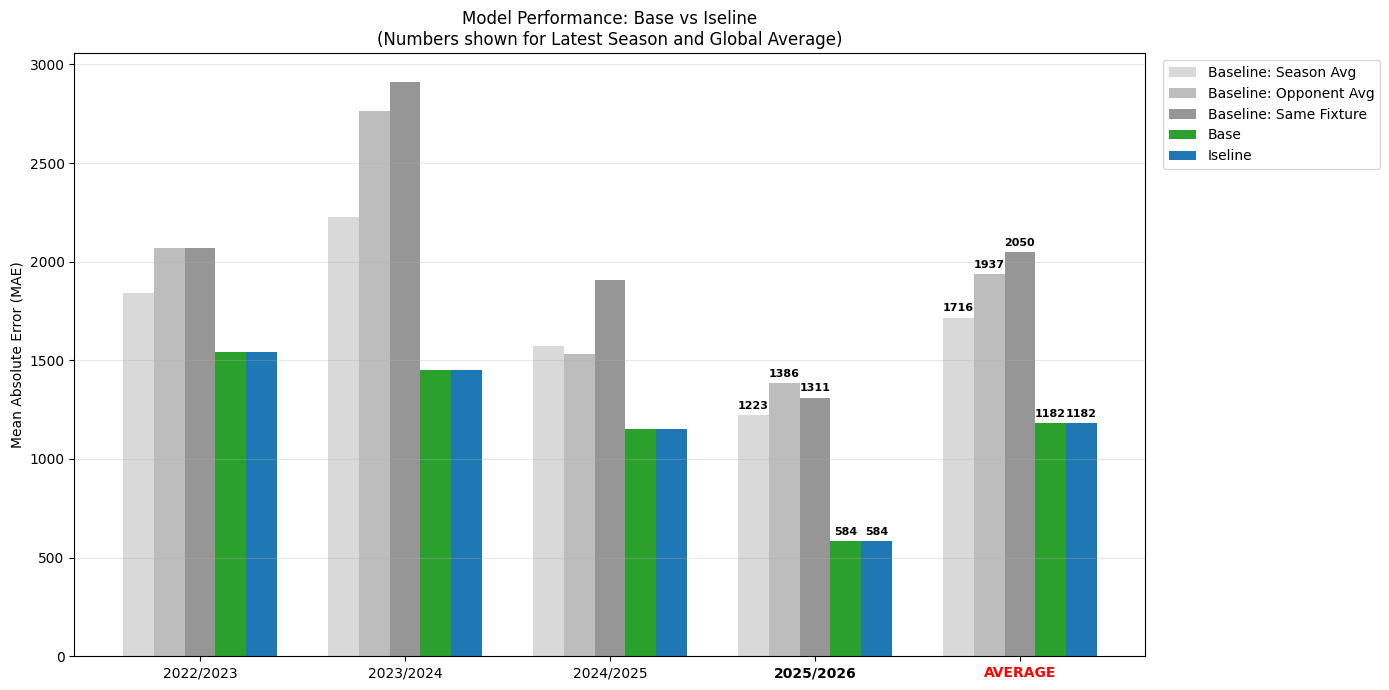


Per-game sequential test on season 2025/2026
  Training on 52 games from prior seasons
  Testing  on 14 games in 2025/2026

  Game 01 vs Sporting Charleroi   | Actual:  4318 | Base:  4915 | Iseline:  4915
  Game 02 vs Genk                 | Actual:  6360 | Base:  4942 | Iseline:  4942
  Game 03 vs Standard Liège       | Actual:  6676 | Base:  6911 | Iseline:  6911
  Game 04 vs Anderlecht           | Actual:  6977 | Base:  7101 | Iseline:  7101
  Game 05 vs Club Brugge          | Actual:  7992 | Base:  6761 | Iseline:  6761
  Game 06 vs Gent                 | Actual:  6373 | Base:  6335 | Iseline:  6335
  Game 07 vs Sint-Truiden         | Actual:  5661 | Base:  5827 | Iseline:  5827
  Game 08 vs Zulte Waregem        | Actual:  4494 | Base:  5723 | Iseline:  5723
  Game 09 vs Cercle Brugge        | Actual:  5812 | Base:  4824 | Iseline:  4824
  Game 10 vs Union Saint-Gilloise | Actual:  5322 | Base:  5285 | Iseline:  5285
  Game 11 vs Mechelen             | Actual:  5971 | Base:  5518 |

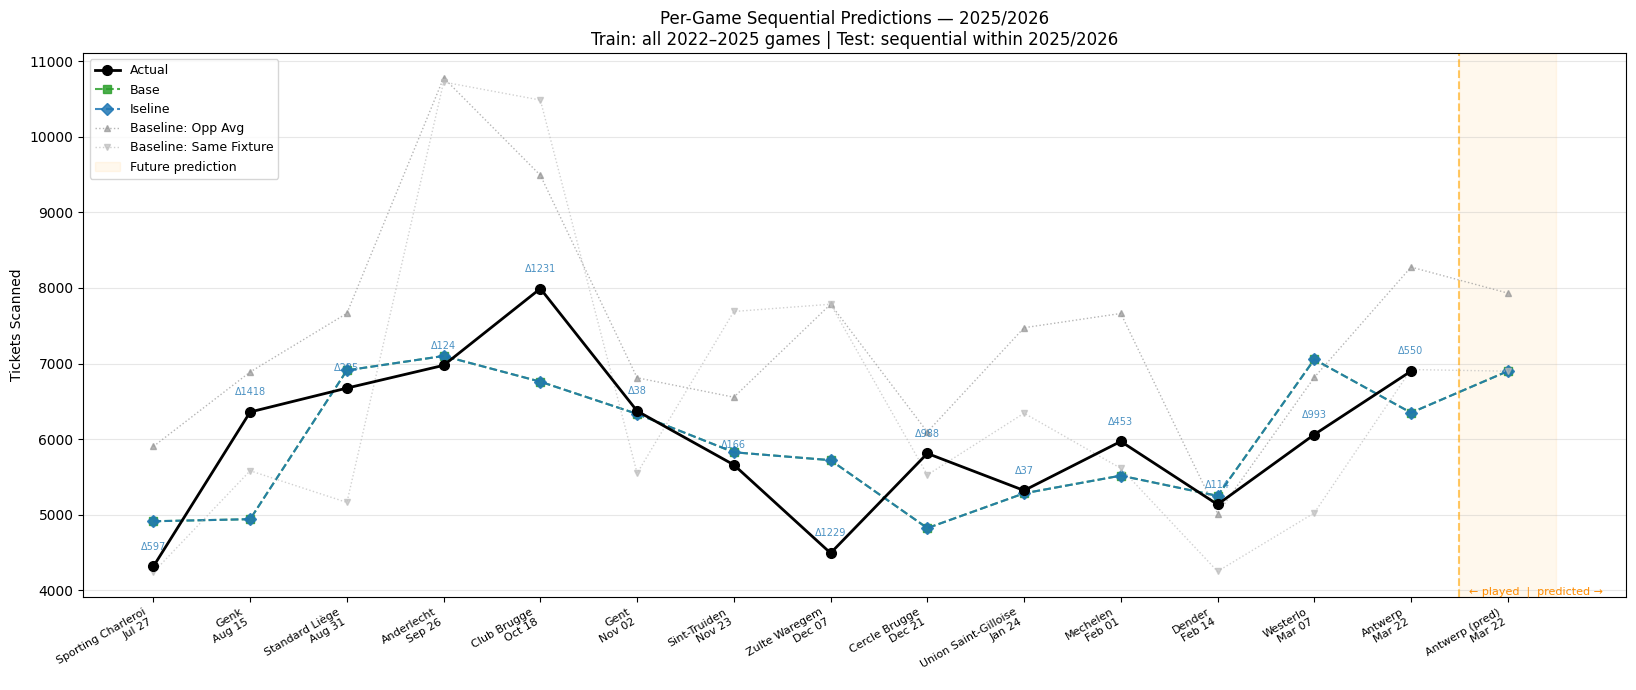


  Chart saved to per_game_2025_2026.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. DATA LOADING & BASELINE PREP
# ==========================================
match   = pd.read_csv("../data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("../data/gold_match_tickets.csv")
context = pd.read_csv("../data/gold_match_context.csv")

match = match[match["is_home_match"] == True]
df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

# Handle potential suffix issues
if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
df["matchday"] = pd.to_numeric(df["matchday"], errors="coerce")
df["is_weekend"] = pd.to_numeric(df["is_weekend"], errors="coerce")
df["academic_week"] = pd.to_numeric(df["academic_week"], errors="coerce")

df["school_holiday_name"] = df["school_holiday_name"].fillna("None").astype(str)
df["is_public_holiday"] = df["is_public_holiday"].fillna("False").astype(str)
df["has_promotion"] = df["has_promotion"].fillna("False").astype(str)

if "stage" not in df.columns:
    df["stage"] = "None"
else:
    df["stage"] = df["stage"].fillna("None").astype(str)

# Rolling & Expanding Averages
df["last_home_attendance"] = df["tickets_scanned"].shift(1)
df["rolling_avg_3"] = df["tickets_scanned"].shift(1).rolling(window=3).mean()
df["rolling_avg_2"] = df["tickets_scanned"].shift(1).rolling(window=2).mean()
df["season_expanding_avg"] = df["tickets_scanned"].shift(1).expanding().mean()

# Opponent Baseline
df["opponent_avg"] = df.groupby("away_team")["tickets_scanned"].transform(
    lambda x: x.shift().expanding().mean()
)
df["opponent_avg"] = df["opponent_avg"].fillna(df["season_expanding_avg"])

# Same Fixture Baseline
df["same_fixture_baseline"] = df.groupby("away_team")["tickets_scanned"].shift(1)
df["same_fixture_baseline"] = df["same_fixture_baseline"].fillna(df["season_expanding_avg"])

# Historical Results
df["last_result_numeric"] = df["last_result_vs_opponent"].str[0].map(
    {'W': 3, 'D': 1, 'L': 0}
).fillna(0)
df["result_minus_2"] = df.groupby("away_team")["last_result_numeric"].shift(1)
df["result_minus_3"] = df.groupby("away_team")["last_result_numeric"].shift(2)
df["points_last_3"] = (
    df["last_result_numeric"].fillna(0) +
    df["result_minus_2"].fillna(0) +
    df["result_minus_3"].fillna(0)
)

# Form & Momentum
eps = 1e-6
df["form_vs_trend"] = df["rolling_avg_3"] - df["season_expanding_avg"]
df["form_ratio"] = df["rolling_avg_3"] / (df["season_expanding_avg"] + eps)
df["momentum_2"] = df["rolling_avg_3"] - df["last_home_attendance"]

# Drop rows where rolling averages can't be calculated
df = df.dropna(subset=["last_home_attendance", "rolling_avg_3"]).reset_index(drop=True)

# ==========================================
# 3. FEATURE SETS  (trib1 & sold removed)
# ==========================================
current_model = [
    "opponent_avg",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
    "away_team",
    "rolling_avg_2",
    "season_expanding_avg",
]
current_model_name = "Base"

new_model = [
    "opponent_avg",
    "matchday",
    "is_weekend",
    "academic_week",
    "stage",
    "away_team",
    "rolling_avg_2",
    "season_expanding_avg"
]
new_model_name = "Iseline"

# ==========================================
# 4. COMPARISON FUNCTION (season-level bars)
# ==========================================
def compare_feature_sets(df, features_1, features_2, name_1="Model 1", name_2="Model 2"):
    if "match_date" in df.columns:
        df = df.sort_values("match_date").reset_index(drop=True)

    seasons = sorted(df["season"].unique())
    season_results = []

    required_cols = list(set(
        features_1 + features_2 +
        ["tickets_scanned", "season", "opponent_avg", "same_fixture_baseline"]
    ))
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    df_clean = df.dropna(subset=required_cols).copy().reset_index(drop=True)

    print(f"{'='*80}")
    print(f"FEATURE SET COMPARISON: {name_1} vs {name_2}")
    print(f"{'='*80}")

    for test_season in seasons:
        df_prior  = df_clean[df_clean["season"] != test_season].copy()
        df_target = df_clean[df_clean["season"] == test_season].copy().reset_index(drop=True)

        if len(df_prior) < 10 or len(df_target) < 5:
            continue

        y_test_actuals = []
        pred_m1_list, pred_m2_list = [], []
        pred_season_list, pred_opp_list, pred_fix_list = [], [], []

        for i in range(len(df_target)):
            test_match   = df_target.iloc[[i]].copy()
            train_matches = pd.concat([df_prior, df_target.iloc[:i]]).copy()

            y_train     = train_matches["tickets_scanned"]
            y_test_val  = test_match["tickets_scanned"].values[0]

            cat_1 = train_matches[features_1].select_dtypes(exclude=[np.number]).columns.tolist()
            X_tr_1 = pd.get_dummies(train_matches[features_1], columns=cat_1, drop_first=True)
            X_te_1 = pd.get_dummies(test_match[features_1], columns=cat_1, drop_first=True).reindex(
                columns=X_tr_1.columns, fill_value=0)

            cat_2 = train_matches[features_2].select_dtypes(exclude=[np.number]).columns.tolist()
            X_tr_2 = pd.get_dummies(train_matches[features_2], columns=cat_2, drop_first=True)
            X_te_2 = pd.get_dummies(test_match[features_2], columns=cat_2, drop_first=True).reindex(
                columns=X_tr_2.columns, fill_value=0)

            rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

            rf.fit(X_tr_1, y_train)
            pred_m1_list.append(rf.predict(X_te_1)[0])

            rf.fit(X_tr_2, y_train)
            pred_m2_list.append(rf.predict(X_te_2)[0])

            y_test_actuals.append(y_test_val)
            pred_season_list.append(train_matches["tickets_scanned"].mean())
            pred_opp_list.append(test_match["opponent_avg"].values[0])
            pred_fix_list.append(test_match["same_fixture_baseline"].values[0])

        if not y_test_actuals:
            continue

        y_test = np.array(y_test_actuals)
        season_results.append({
            "season": test_season,
            "Baseline: Season Avg":  mean_absolute_error(y_test, pred_season_list),
            "Baseline: Opponent Avg": mean_absolute_error(y_test, pred_opp_list),
            "Baseline: Same Fixture": mean_absolute_error(y_test, pred_fix_list),
            name_1: mean_absolute_error(y_test, pred_m1_list),
            name_2: mean_absolute_error(y_test, pred_m2_list),
        })
        print(f"✓ Season {test_season} processed.")

    results_df = pd.DataFrame(season_results).set_index("season")
    latest_season_name = results_df.index[-1]
    results_df.loc["AVERAGE"] = results_df.mean()

    print(f"\n{'='*60}")
    print(f"{'FINAL PERFORMANCE SUMMARY':^60}")
    print(f"{'='*60}")
    print(f"{'Metric':<25} | {'Latest ('+str(latest_season_name)+')':<15} | {'Overall Avg':<12}")
    print("-" * 60)
    for col in results_df.columns:
        latest_val = results_df.loc[latest_season_name, col]
        avg_val    = results_df.loc["AVERAGE", col]
        print(f"{col:<25} | {latest_val:<15.0f} | {avg_val:<12.0f}")
    print(f"{'='*60}\n")

    cols   = ["Baseline: Season Avg","Baseline: Opponent Avg","Baseline: Same Fixture", name_1, name_2]
    colors = ["#d9d9d9","#bdbdbd","#969696","#2ca02c","#1f77b4"]

    x     = np.arange(len(results_df))
    width = 0.15
    fig, ax = plt.subplots(figsize=(14, 7))
    offsets = [-2*width, -width, 0, width, 2*width]

    for i, (col, color) in enumerate(zip(cols, colors)):
        rects = ax.bar(x + offsets[i], results_df[col], width=width, label=col, color=color)
        for j, rect in enumerate(rects):
            row_name = results_df.index[j]
            if row_name == latest_season_name or row_name == "AVERAGE":
                height = rect.get_height()
                ax.annotate(f'{height:.0f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(results_df.index)
    labels = ax.get_xticklabels()
    for lbl in labels:
        if lbl.get_text() == "AVERAGE":
            lbl.set_weight("bold"); lbl.set_color("red")
        if lbl.get_text() == str(latest_season_name):
            lbl.set_weight("bold"); lbl.set_color("black")

    ax.set_ylabel("Mean Absolute Error (MAE)")
    ax.set_title(f"Model Performance: {name_1} vs {name_2}\n(Numbers shown for Latest Season and Global Average)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results_df

def plot_per_game_latest_season(
    df,
    features_1, features_2,
    name_1="Model 1", name_2="Model 2",
    latest_season="2025/2026",
    antwerp_date="2026-03-22",
):

    required_cols = list(set(
        features_1 + features_2 +
        ["tickets_scanned", "season", "opponent_avg", "same_fixture_baseline",
         "match_date", "away_team"]
    ))
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    df_clean = df.dropna(subset=required_cols).copy().reset_index(drop=True)
    df_clean = df_clean.sort_values("match_date").reset_index(drop=True)

    df_prior  = df_clean[df_clean["season"] != latest_season].copy()
    df_target = df_clean[df_clean["season"] == latest_season].copy().reset_index(drop=True)

    print(f"\nPer-game sequential test on season {latest_season}")
    print(f"  Training on {len(df_prior)} games from prior seasons")
    print(f"  Testing  on {len(df_target)} games in {latest_season}\n")

    dates, opponents, actuals = [], [], []
    pred_m1, pred_m2 = [], []
    pred_opp_bl, pred_fix_bl = [], []

    for i in range(len(df_target)):
        test_match    = df_target.iloc[[i]].copy()
        train_matches = pd.concat([df_prior, df_target.iloc[:i]]).copy()

        y_train    = train_matches["tickets_scanned"]
        y_test_val = test_match["tickets_scanned"].values[0]

        cat_1 = train_matches[features_1].select_dtypes(exclude=[np.number]).columns.tolist()
        X_tr_1 = pd.get_dummies(train_matches[features_1], columns=cat_1, drop_first=True)
        X_te_1 = pd.get_dummies(test_match[features_1], columns=cat_1, drop_first=True).reindex(
            columns=X_tr_1.columns, fill_value=0)

        cat_2 = train_matches[features_2].select_dtypes(exclude=[np.number]).columns.tolist()
        X_tr_2 = pd.get_dummies(train_matches[features_2], columns=cat_2, drop_first=True)
        X_te_2 = pd.get_dummies(test_match[features_2], columns=cat_2, drop_first=True).reindex(
            columns=X_tr_2.columns, fill_value=0)

        rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        rf.fit(X_tr_1, y_train); p1 = rf.predict(X_te_1)[0]
        rf.fit(X_tr_2, y_train); p2 = rf.predict(X_te_2)[0]

        dates.append(test_match["match_date"].values[0])
        opponents.append(test_match["away_team"].values[0])
        actuals.append(y_test_val)
        pred_m1.append(p1)
        pred_m2.append(p2)
        pred_opp_bl.append(test_match["opponent_avg"].values[0])
        pred_fix_bl.append(test_match["same_fixture_baseline"].values[0])

        print(f"  Game {i+1:02d} vs {test_match['away_team'].values[0]:<20} "
              f"| Actual: {y_test_val:>5.0f} "
              f"| {name_1}: {p1:>5.0f} "
              f"| {name_2}: {p2:>5.0f}")

    # ---- ANTWERP FUTURE PREDICTION ----
    # Build a synthetic row for Antwerp.
    # Use the most recent row with away_team == "Royal Antwerp FC" (or "Antwerp")
    # as the template for opponent-specific features; update rolling features
    # from the current state of the df (all 2025/2026 played games + prior).
    all_train_for_antwerp = pd.concat([df_prior, df_target]).copy()
    all_train_for_antwerp = all_train_for_antwerp.sort_values("match_date").reset_index(drop=True)

    antwerp_candidates = all_train_for_antwerp[
        all_train_for_antwerp["away_team"].str.contains("Antwerp", case=False, na=False)
    ]

    antwerp_row = None
    if not antwerp_candidates.empty:
        antwerp_template = antwerp_candidates.iloc[-1].copy()

        antwerp_row = antwerp_template.copy()
        antwerp_row["match_date"] = pd.Timestamp(antwerp_date)
        antwerp_row["tickets_scanned"] = np.nan  # unknown

        # Update rolling features from the full training set
        recent_scanned = all_train_for_antwerp["tickets_scanned"].values
        antwerp_row["rolling_avg_3"]       = np.mean(recent_scanned[-3:])
        antwerp_row["rolling_avg_2"]       = np.mean(recent_scanned[-2:])
        antwerp_row["last_home_attendance"]= recent_scanned[-1]
        antwerp_row["season_expanding_avg"]= np.mean(recent_scanned)
        antwerp_row["form_vs_trend"]       = antwerp_row["rolling_avg_3"] - antwerp_row["season_expanding_avg"]
        antwerp_row["form_ratio"]          = antwerp_row["rolling_avg_3"] / (antwerp_row["season_expanding_avg"] + eps)
        antwerp_row["momentum_2"]          = antwerp_row["rolling_avg_3"] - antwerp_row["last_home_attendance"]

        # Opponent average for Antwerp
        ant_hist = antwerp_candidates["tickets_scanned"].values
        antwerp_row["opponent_avg"]          = np.mean(ant_hist)
        antwerp_row["same_fixture_baseline"] = ant_hist[-1] if len(ant_hist) > 0 else antwerp_row["season_expanding_avg"]

        antwerp_df = pd.DataFrame([antwerp_row])
        y_train_ant = all_train_for_antwerp["tickets_scanned"]

        cat_1 = all_train_for_antwerp[features_1].select_dtypes(exclude=[np.number]).columns.tolist()
        X_tr_1 = pd.get_dummies(all_train_for_antwerp[features_1], columns=cat_1, drop_first=True)
        X_te_1 = pd.get_dummies(antwerp_df[features_1], columns=cat_1, drop_first=True).reindex(
            columns=X_tr_1.columns, fill_value=0)

        cat_2 = all_train_for_antwerp[features_2].select_dtypes(exclude=[np.number]).columns.tolist()
        X_tr_2 = pd.get_dummies(all_train_for_antwerp[features_2], columns=cat_2, drop_first=True)
        X_te_2 = pd.get_dummies(antwerp_df[features_2], columns=cat_2, drop_first=True).reindex(
            columns=X_tr_2.columns, fill_value=0)

        rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        rf.fit(X_tr_1, y_train_ant); ant_p1 = rf.predict(X_te_1)[0]
        rf.fit(X_tr_2, y_train_ant); ant_p2 = rf.predict(X_te_2)[0]

        dates.append(pd.Timestamp(antwerp_date))
        opponents.append("Antwerp (pred)")
        actuals.append(np.nan)           # no actual yet
        pred_m1.append(ant_p1)
        pred_m2.append(ant_p2)
        pred_opp_bl.append(antwerp_row["opponent_avg"])
        pred_fix_bl.append(antwerp_row["same_fixture_baseline"])

        print(f"\n  [FUTURE] vs Antwerp on {antwerp_date}: {name_1}: {ant_p1:.0f} | {name_2}: {ant_p2:.0f}")
    else:
        print("\n  [WARNING] No historical Antwerp rows found; skipping future prediction.")

    # ---- MAE for played games only ----
    played_mask = [not np.isnan(a) for a in actuals]
    if any(played_mask):
        y_played   = np.array([a for a, m in zip(actuals, played_mask) if m])
        p1_played  = np.array([p for p, m in zip(pred_m1, played_mask) if m])
        p2_played  = np.array([p for p, m in zip(pred_m2, played_mask) if m])
        ob_played  = np.array([p for p, m in zip(pred_opp_bl, played_mask) if m])
        fb_played  = np.array([p for p, m in zip(pred_fix_bl, played_mask) if m])
        print(f"\n  MAE (played games only):")
        print(f"    Opp Baseline : {mean_absolute_error(y_played, ob_played):.0f}")
        print(f"    Fix Baseline : {mean_absolute_error(y_played, fb_played):.0f}")
        print(f"    {name_1:<14}: {mean_absolute_error(y_played, p1_played):.0f}")
        print(f"    {name_2:<14}: {mean_absolute_error(y_played, p2_played):.0f}")

    # ---- PLOT ----
    x_idx   = np.arange(len(dates))
    x_labels= [f"{opp}\n{pd.Timestamp(d).strftime('%b %d')}" for opp, d in zip(opponents, dates)]
    is_future = [np.isnan(a) for a in actuals]

    fig, ax = plt.subplots(figsize=(max(14, len(dates) * 1.1), 7))

    # Actual attendance (played games)
    actual_vals = [a if not np.isnan(a) else None for a in actuals]
    ax.plot(
        [i for i, v in enumerate(actual_vals) if v is not None],
        [v for v in actual_vals if v is not None],
        'ko-', linewidth=2, markersize=7, label="Actual", zorder=5
    )

    # Model predictions
    ax.plot(x_idx, pred_m1, 's--', color='#2ca02c', linewidth=1.5, markersize=6, label=name_1, alpha=0.85)
    ax.plot(x_idx, pred_m2, 'D--', color='#1f77b4', linewidth=1.5, markersize=6, label=name_2, alpha=0.85)

    # Baselines
    ax.plot(x_idx, pred_opp_bl, '^:', color='#969696', linewidth=1, markersize=5, label="Baseline: Opp Avg", alpha=0.7)
    ax.plot(x_idx, pred_fix_bl, 'v:', color='#bdbdbd', linewidth=1, markersize=5, label="Baseline: Same Fixture", alpha=0.7)

    # Shade future prediction area
    if any(is_future):
        future_start = next(i for i, f in enumerate(is_future) if f)
        ax.axvspan(future_start - 0.5, len(dates) - 0.5,
                   alpha=0.07, color='orange', label="Future prediction")
        ax.axvline(future_start - 0.5, color='orange', linewidth=1.5, linestyle='--', alpha=0.6)
        ax.text(future_start - 0.4, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0,
                "← played  |  predicted →", fontsize=8, color='darkorange', va='bottom')

    # Error annotations for played games
    for i, (p1, p2, a) in enumerate(zip(pred_m1, pred_m2, actuals)):
        if not np.isnan(a):
            e1 = abs(p1 - a); e2 = abs(p2 - a)
            better = name_1 if e1 < e2 else name_2
            color  = '#2ca02c' if better == name_1 else '#1f77b4'
            ax.annotate(f'Δ{min(e1,e2):.0f}',
                        xy=(i, a), xytext=(0, 12), textcoords='offset points',
                        ha='center', fontsize=7, color=color, alpha=0.8)

    ax.set_xticks(x_idx)
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel("Tickets Scanned")
    ax.set_title(f"Per-Game Sequential Predictions — {latest_season}\n"
                 f"Train: all 2022–2025 games | Test: sequential within {latest_season}")
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig("per_game_2025_2026.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  Chart saved to per_game_2025_2026.png")


# ==========================================
# 6. RUN
# ==========================================

# --- Season-level bar chart ---
results_df = compare_feature_sets(
    df=df,
    features_1=current_model,
    features_2=new_model,
    name_1=current_model_name,
    name_2=new_model_name,
)

# --- Per-game chart for 2025/2026 + Antwerp prediction ---
plot_per_game_latest_season(
    df=df,
    features_1=current_model,
    features_2=new_model,
    name_1=current_model_name,
    name_2=new_model_name,
    latest_season="2025/2026",       # adjust if your season label differs
    antwerp_date="2026-03-22",
)
  Game 14 vs Antwerp              | Actual:  1000 | Base:  6350 | Iseline:  6409
